In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/train.csv")

df.head()           # first 5 rows
df.shape            # (rows, columns)
df.info()           # data types
df.describe()       # stats summary
df.isnull().sum()   # missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"], errors="ignore")

In [9]:
# Family size (how many people travelling together including themselves)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Is the passenger alone?
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Age groups
df["AgeGroup"] = pd.cut(df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle-Age", "Senior"])

# Fare categories
df["FareBand"] = pd.qcut(df["Fare"], q=4,
    labels=["Low", "Medium", "High", "Very High"])

# Verify new columns
df[["FamilySize", "IsAlone", "AgeGroup", "FareBand"]].head(10)

,FamilySize,IsAlone,AgeGroup,FareBand
0,2,0,Adult,Low
1,2,0,Middle-Age,Very High
2,1,1,Adult,Medium
3,2,0,Adult,Very High
4,1,1,Adult,Medium
5,1,1,Adult,Medium
6,1,1,Middle-Age,Very High
7,5,0,Child,High
8,3,0,Adult,Medium
9,2,0,Teen,High


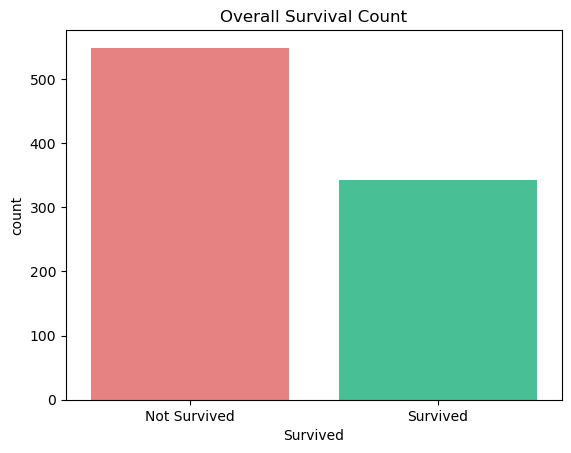

In [11]:
sns.countplot(x="Survived", hue="Survived", data=df,
              palette=["#f87171", "#34d399"], legend=False)
plt.title("Overall Survival Count")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()


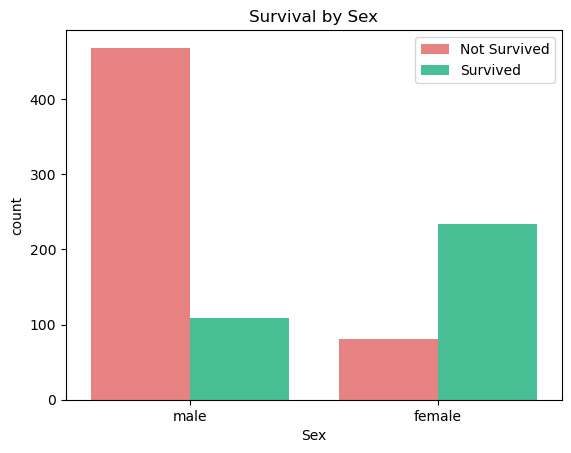

In [13]:
sns.countplot(x="Sex", hue="Survived", data=df, palette=["#f87171", "#34d399"])
plt.title("Survival by Sex")
plt.legend(["Not Survived", "Survived"])
plt.show()

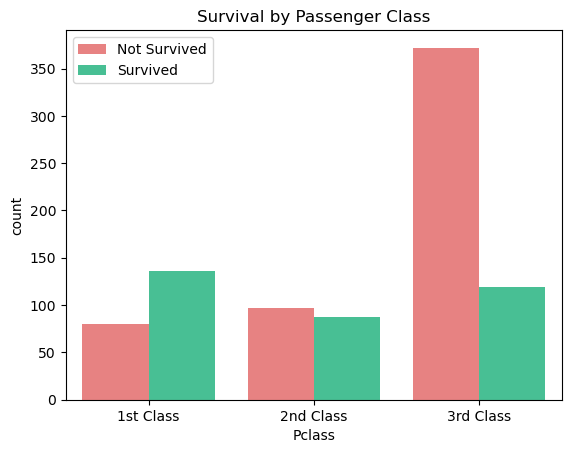

In [14]:
sns.countplot(x="Pclass", hue="Survived", data=df, palette=["#f87171", "#34d399"])
plt.title("Survival by Passenger Class")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])
plt.legend(["Not Survived", "Survived"])
plt.show()

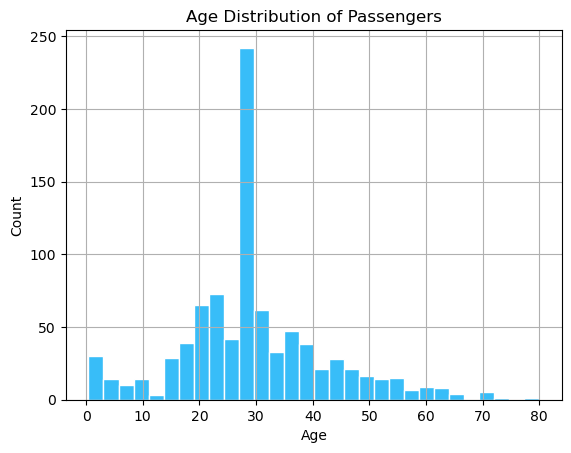

In [15]:
df["Age"].hist(bins=30, color="#38bdf8", edgecolor="white")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

C:\Users\shivakumar\AppData\Local\Temp\ipykernel_14272\3420786913.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df, palette=["#f87171", "#34d399"])


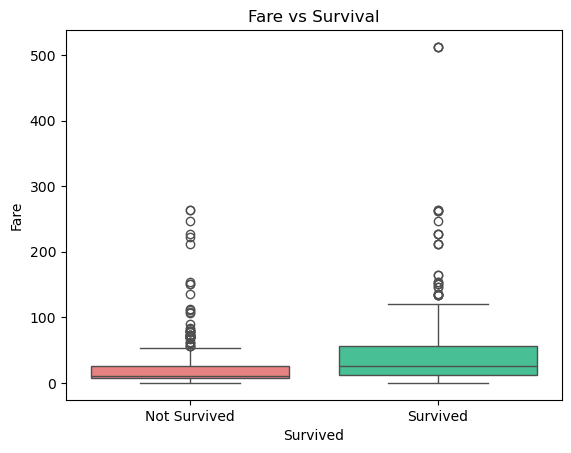

In [16]:
sns.boxplot(x="Survived", y="Fare", data=df, palette=["#f87171", "#34d399"])
plt.title("Fare vs Survival")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

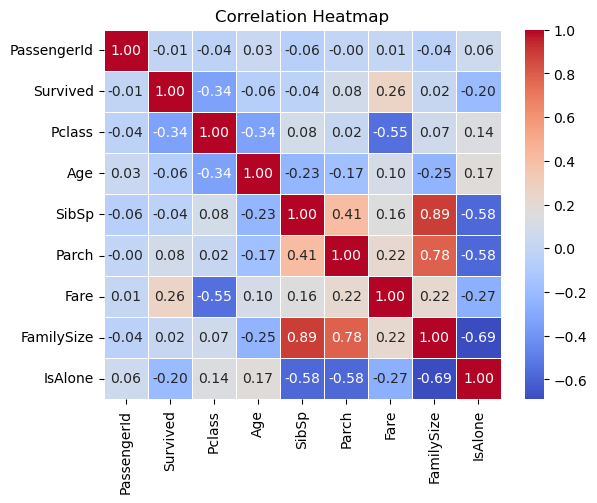

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

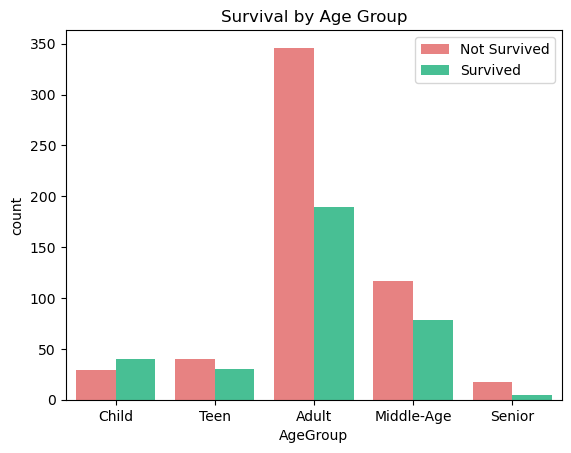

In [18]:
sns.countplot(x="AgeGroup", hue="Survived", data=df, palette=["#f87171", "#34d399"])
plt.title("Survival by Age Group")
plt.legend(["Not Survived", "Survived"])
plt.show()

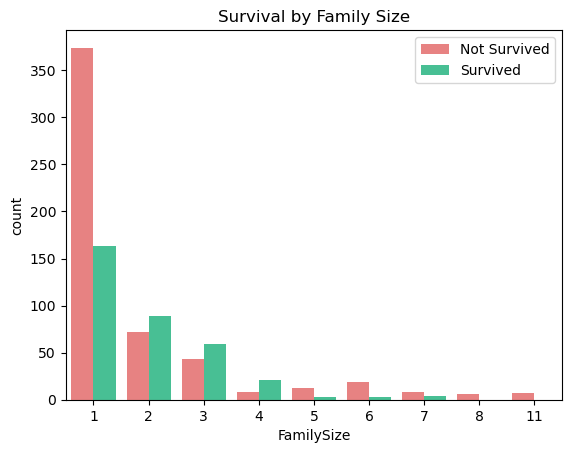

In [19]:
sns.countplot(x="FamilySize", hue="Survived", data=df, palette=["#f87171", "#34d399"])
plt.title("Survival by Family Size")
plt.legend(["Not Survived", "Survived"])
plt.show()